In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

init = np.array([
    [0.7, 0.9],
    [0.8, 0.9],
    [0.4, 0.2],
    [0.1, 0.5],
    [0.25,  0.21] ,
    [0.3996, 0.1390], 
    [0.3036,  0.1536], 
    [0.978, 0.9703], 
    [0.9204, 0.586]
    
])

In [ ]:
import numpy as NP
from config import seed

random_generator = NP.random.RandomState(seed)
random_sampling = NP.random.RandomState()

def dim_models(lower_bounds, upper_bounds, models):
    return lower_bounds + (upper_bounds - lower_bounds) * models

def generate_random_models(n, nd):
    return random_generator.random_sample((n, nd))

def get_bests_indices(nr, misfits, np_current):
    return NP.argsort(misfits[:np_current])[:nr]

def sampling(ns, nd, nr, models, np_current, misfits):
    new_models = NP.zeros((ns, nd))
    
    best_indices = get_bests_indices(nr, misfits, np_current)
    m = models[:np_current, :]
    
    global_best_idx = best_indices[0]
    
    idx_new = 0
    for k in best_indices:

        walk_length = int(NP.floor(ns / nr))
        if k == global_best_idx:
            walk_length += int(ns % nr)
            
        vk = m[k].copy()
        
        for step in range(walk_length):
            xA = vk.copy()             
            d2 = NP.sum((m - xA) ** 2, axis=1)            
            axes = random_generator.permutation(nd)
            
            for i in axes:
                dk2 = d2[k]                
                vji = m[:, i]
                a = (dk2 - d2)
                b = (vk[i] - vji)                
                xji = 0.5 * (vk[i] + vji + NP.divide(a, b, out=NP.zeros_like(a), where=b != 0))

                li = NP.nanmax(NP.hstack((0, xji[xji < xA[i]])))
                ui = NP.nanmin(NP.hstack((1, xji[xji > xA[i]])))
                
                xA_old_i = xA[i]
                xA[i] = (ui - li) * random_sampling.random_sample() + li
                
                d2 = d2 - (m[:, i] - xA_old_i)**2 + (m[:, i] - xA[i])**2
            
            if idx_new < ns:
                new_models[idx_new] = xA.copy()
                idx_new += 1
                
    return new_models

In [ ]:
sampling(ns, nd, nr, models, np_current, misfits)

In [5]:
random_generator = np.random.RandomState(42)

def generate_random_models(n, nd):
    return random_generator.random_sample((n, nd))
def rosenbrock(params, a=1, b=100):
    x = params[:, 0]
    y = params[:, 1]
    return np.log10((a - x) ** 2 + b * (y - x**2) ** 2)

lb = np.array([0, 0])
ub = np.array([1.2, 1.2])
background = lb + (ub - lb) * generate_random_models(50000, 2)
mfits = rosenbrock(background)

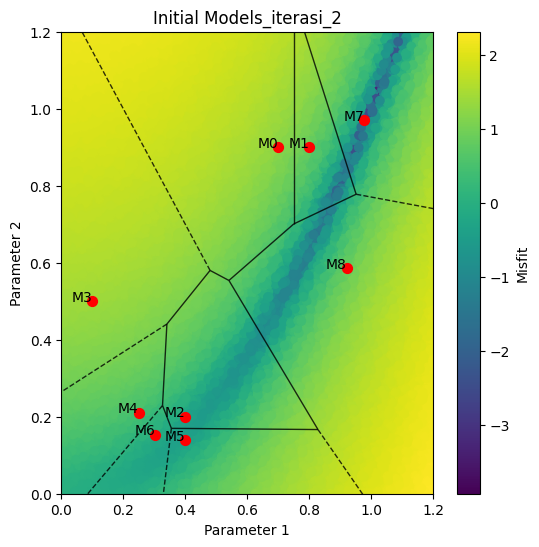

In [6]:
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

fig, ax = plt.subplots(figsize=(6,6))

# background models
sc = ax.scatter(background[:, 0], background[:, 1],
                c=mfits, cmap='viridis', alpha=1)

# init models
ax.scatter(init[:, 0], init[:, 1], color='red', s=50)

# voronoi
vor = Voronoi(init)
voronoi_plot_2d(vor, ax=ax,
                show_vertices=False,
                line_colors='black',
                line_width=1,
                line_alpha=0.8,
                point_size=0)

# label titik init
for i, (x, y) in enumerate(init):
    if i >= 100:
        ax.text(x, y, f"M{i}", fontsize=10, ha='left', color='blue')
    else:
        ax.text(x, y, f"M{i}", fontsize=10, ha='right')

ax.set_xlabel('Parameter 1')
ax.set_ylabel('Parameter 2')
ax.set_title('Initial Models_iterasi_2')

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)

fig.colorbar(sc, label='Misfit')

plt.show()